<a href="https://colab.research.google.com/github/dyyqrn/Predict-Daily-Gold-Returns/blob/main/Predict_Daily_Gold_Returns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load Data

In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor


In [119]:
gold = pd.read_csv('Antam_historical_gold_prices.csv')

# Preprocessing

In [120]:
gold.head()

,Time (ms),Gold Price,Date
0,1262596020000,408000,2010-01-04 09:07:00
1,1262683680000,410000,2010-01-05 09:28:00
2,1262761260000,410000,2010-01-06 07:01:00
3,1262857500000,412000,2010-01-07 09:45:00
4,1262943420000,410000,2010-01-08 09:37:00


In [121]:
gold.tail()

,Time (ms),Gold Price,Date
4888,1763454309000,2322000,2025-11-18 08:25:09
4889,1763454310000,2322000,2025-11-18 08:25:10
4890,1763454311000,2322000,2025-11-18 08:25:11
4891,1763541343000,2343000,2025-11-19 08:35:43
4892,1763628635000,2364000,2025-11-20 08:50:35


In [122]:
print("Earliest date:", gold['Date'].min())
print("Latest date:", gold['Date'].max())

Earliest date: 2010-01-04 09:07:00
Latest date: 2025-11-20 08:50:35


In [123]:
gold.shape

(4893, 3)

In [124]:
gold.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4893 entries, 0 to 4892
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Time (ms)   4893 non-null   int64 
 1   Gold Price  4893 non-null   int64 
 2   Date        4893 non-null   object
dtypes: int64(2), object(1)
memory usage: 114.8+ KB


In [125]:
gold.isnull().sum()

,0
Time (ms),0
Gold Price,0
Date,0


In [126]:
gold.describe()

,Time (ms),Gold Price
count,4.893000e+03,4.893000e+03
mean,1.533083e+12,8.520455e+05
std,1.447581e+11,3.988312e+05
min,1.262596e+12,3.940000e+05
25%,1.414022e+12,5.720000e+05
50%,1.543043e+12,6.690000e+05
75%,1.659774e+12,9.990000e+05
max,1.763629e+12,2.487000e+06


In [127]:
gold['Date'] = pd.to_datetime(gold['Date'])
gold = gold.sort_values('Date')
gold = gold.reset_index(drop=True)

# Feature Engineering

Create Log Return

In [128]:
gold['log_return'] = np.log(gold['Gold Price'] / gold['Gold Price'].shift(1))

In [129]:
gold = gold.dropna()

Create Lag Features and Rolling Features

In [130]:
gold['lag_1'] = gold['log_return'].shift(1)
gold['lag_2'] = gold['log_return'].shift(2)
gold['lag_3'] = gold['log_return'].shift(3)
gold['lag_7'] = gold['log_return'].shift(7)
gold['lag_14'] = gold['log_return'].shift(14)
gold['lag_30'] = gold['log_return'].shift(30)
gold['lag_90'] = gold['log_return'].shift(90)

In [131]:
gold['rolling_mean_7'] = gold['log_return'].rolling(window=7).mean()

gold['rolling_std_7'] = gold['log_return'].rolling(window=7).std()

In [132]:
gold = gold.dropna()

In [133]:
X = gold[['lag_1','lag_2','lag_3','lag_7','lag_14','lag_30', 'lag_90',
          'rolling_mean_7','rolling_std_7']]
Y = gold['log_return']

# Train Test Split

Use Time Based Split

In [134]:
train = gold[gold['Date'] < '2023-01-01']
test = gold[gold['Date'] >= '2023-01-01']

X_train = train[X.columns]
X_test = test[X.columns]

Y_train = train['log_return']
Y_test = test['log_return']

Train the Model

## Linear Regression

In [137]:
lr = LinearRegression()
lr.fit(X_train, Y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression Test R2:", r2_score(Y_test, lr_pred))
print("Linear Regression Test MAE:", mean_absolute_error(Y_test, lr_pred))
print("Linear Regression Test RMSE:", np.sqrt(mean_squared_error(Y_test, lr_pred)))

Linear Regression Test R2: 0.1921828556256967
Linear Regression Test MAE: 0.004735318577837845
Linear Regression Test RMSE: 0.006398081140873418


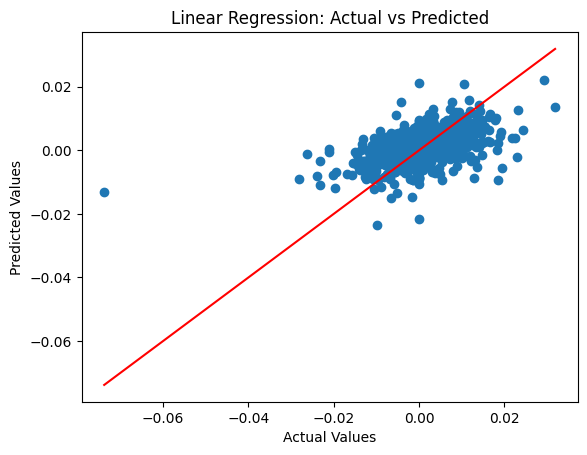

In [138]:
plt.scatter(Y_test, lr_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted")

# perfect prediction line
plt.plot(
    [Y_test.min(), Y_test.max()],
    [Y_test.min(), Y_test.max()],
    color='red'
)

plt.show()

## Random Forest Regressor

In [139]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42
)

model.fit(X_train, Y_train)

RandomForestRegressor(max_depth=6, min_samples_leaf=5, n_estimators=200,
                      random_state=42)

In [140]:
print("Train R2:", model.score(X_train, Y_train))
print("Test R2:", model.score(X_test, Y_test))

Train R2: 0.34666646802843737
Test R2: 0.19541532680612217


Prediction

In [141]:
Y_pred = model.predict(X_test)

Evaluate

In [142]:
mae = mean_absolute_error(Y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))

print('MAE:', mae)
print('RMSE:', rmse)

MAE: 0.00460227558688907
RMSE: 0.006385267384783926


In [143]:
y_pred = model.predict(X_test)

In [144]:
comparison = pd.DataFrame({'Actual': Y_test, 'Predicted': Y_pred})
print(comparison.head())

        Actual  Predicted
3817  0.000000   0.001561
3818  0.000000   0.002352
3819 -0.003906   0.002350
3820  0.001955   0.003094
3821  0.006813   0.003483


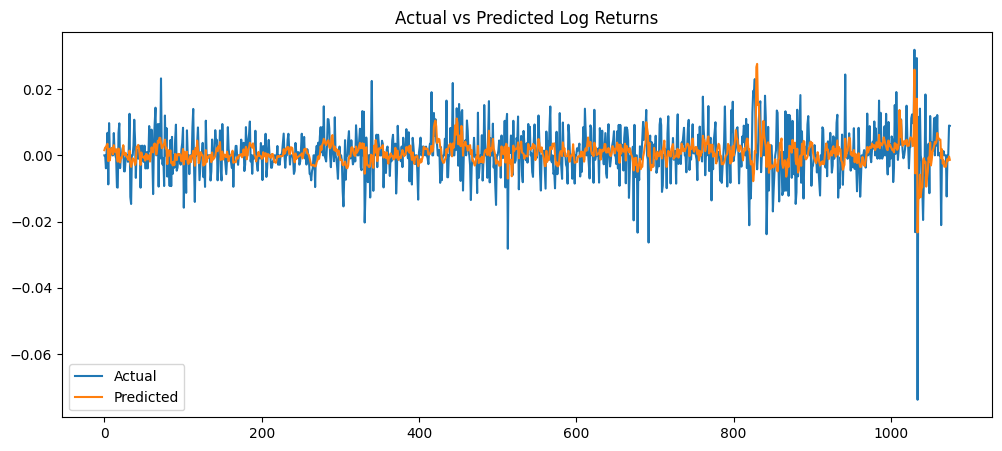

In [145]:
plt.figure(figsize=(12,5))
plt.plot(Y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Log Returns")
plt.show()